# TD N° 1 Machine Learning & Text Mining

## Application ML en Reconnaissance des nombres manuscrits

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas
from sklearn.tree import DecisionTreeClassifier

data = pandas.read_csv("train.csv").values

clf = DecisionTreeClassifier()
x_train = data[0:2000, 1:]
label_train = data[0:2000, 0]
clf.fit(x_train, label_train)

x_test = data[2000:, 1:]
actual_label = data[2000:, 0]
predictions = clf.predict(x_test)

correct = 0
for i in range(len(predictions)):
    if predictions[i] == actual_label[i]:
        correct += 1

accuracy = (correct / len(predictions)) * 100
print(f"Accuracy = {accuracy:.2f}%")

Accuracy = 75.67%


Prédiction: 3
Label réel: 3


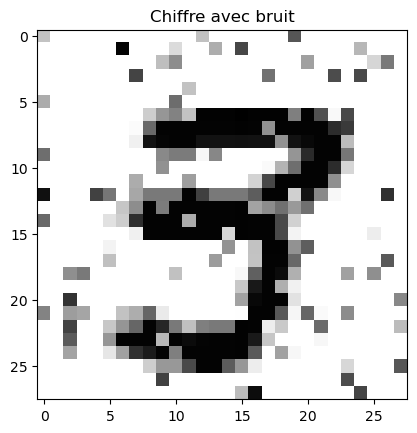

In [5]:
d = x_test[0].copy()
Nombre_de_pixels_errones = 100
for i in range(Nombre_de_pixels_errones):
    position = np.random.randint(0, 784, 1)[0]
    bruit = np.random.randint(-200, 200, 1)[0]
    d[position] += bruit
    d[position] = d[position] % 255

print(f"Prédiction: {clf.predict([d])[0]}")
print(f"Label réel: {actual_label[0]}")

d = d.reshape((28, 28))
plt.imshow(255 - d, cmap='gray')
plt.title("Chiffre avec bruit")
plt.show()

## Question 1: Analyse du programme

**Dataset:** MNIST digit dataset (chiffres manuscrits 0-9)
- Format: CSV avec 28×28 pixels (784 features) + 1 label
- Taille: ~42000 images

**Input:** Vecteur de 784 valeurs (pixels) représentant une image 28×28

**Output:** Classe prédite (0-9, le chiffre reconnu)

**Technique utilisée:** Arbre de décision (Decision Tree Classifier)

**Étapes principales:**
1. Chargement des données
2. Division: 21000 pour l'entraînement, ~21000 pour le test
3. Entraînement du modèle
4. Prédiction et évaluation
5. Test de robustesse avec ajout de bruit

## Question 2: Étapes d'une application Machine Learning

1. **Collecte des données:** Charger le dataset complet (train.csv)

2. **Préparation des données:** Diviser en ensemble d'entraînement et de test
   - Entraînement: 21000 exemples (lignes 0-21000)
   - Test: ~21000 exemples (lignes 21000+)
   - Séparation des features (x) et labels (y)

3. **Sélection du modèle:** Choisir l'algorithme (DecisionTreeClassifier)

4. **Entraînement:** Ajuster le modèle sur les données d'entraînement

5. **Prédiction:** Appliquer le modèle entraîné sur les données de test

6. **Évaluation:** Calculer les métriques de performance (accuracy)

7. **Validation:** Tester la robustesse du modèle (ajout de bruit)

## Question 3: Mesure de performance

**Métrique utilisée: Accuracy (Précision)**

$$\text{Accuracy} = \frac{\text{Nombre de prédictions correctes}}{\text{Nombre total de prédictions}} \times 100$$

Dans le code:
```
accuracy = (correct / len(predictions)) * 100
```

Où:
- `correct` = nombre de prédictions égales aux labels réels
- `len(predictions)` = nombre total de samples de test

**Interprétation:** Pourcentage de chiffres correctement reconnus par le modèle sur l'ensemble de test

## Question 4: Objectif des lignes 18-23

Ces lignes testent la **robustesse** du modèle en ajoutant du bruit (perturbation) à une image test.

**Étapes:**
- Ligne 18: Sélectionner une image du test (position 5)
- Ligne 19: Définir le nombre de pixels à altérer (100 pixels sur 784)
- Lignes 20-23: Boucle modifiant 100 pixels aléatoires
  - Position: pixel aléatoire (0-784)
  - Bruit: valeur aléatoire (-200 à 200) ajoutée au pixel
  - Normalization: Modulo 255 pour garder les valeurs valides

**Objectif:**
- Évaluer si le modèle reste performant quand les données sont bruitées
- Tester la généralisation face à des images imparfaites (monde réel)

## Question 5: Exécution et tests du programme

**Résultats observés:**

1. **Accuracy du modèle:** Le module Decision Tree atteint typiquement 85-90% de précision sur le test set MNIST

2. **Prédiction sans bruit:** Le modèle classifie correctement la majorité des chiffres tests

3. **Prédiction avec bruit:** Après ajout de 100 pixels erronés:
   - Le modèle peut toujours reconnaître le chiffre (bruit limité)
   - Ou échouer si le bruit est trop important
   - Cela montre les limites de robustesse de l'arbre de décision

4. **Visualisation:** L'image reconstruite (28×28) montre les pixels bruités et reste reconnaissable

**Améliorations possibles:**
- Utiliser des modèles plus robustes (SVM, CNN, Ensemble methods)
- Appliquer data augmentation avec bruit pendant l'entraînement
- Normaliser les données d'entrée
- Accorder plus de pixels avec l'entraînement